# Interactive target-selection guide

This notebook is the executable companion to the Read the Docs guide. It uses the public `target_selection` API, runs in order, and adapts to **planning-only**, one-reference, and multi-reference configurations.

The scientific logic remains in the installed Python modules. The notebook is limited to configuration, execution, inspection, and observer-facing exports, so CLI and notebook runs remain equivalent.


## Mental model

| Source role | Question it answers | Examples |
|---|---|---|
| Target provider | Which events should be considered? | MOP, a user CSV, future OMP |
| Follow-up survey | Which events and epochs has the observing program already covered? | CASLEO/HSH, CASLEO/JS |
| Reference survey | What external visits, images, or photometry add context? | Rubin DP1, DP2 |

The workflow builds one canonical target union, calculates local observing feasibility, optionally enriches it with each reference survey, and generates only the requested products.


## 1. Choose and inspect the configuration

Copy `configs/example.toml` for a real run and edit the copy. Frequently changed dates, active sources, visibility cuts, and product switches are at the top of the file.


In [1]:
from dataclasses import asdict
from importlib import reload
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

# Reload local development modules so this notebook sees changes made in an
# editable checkout even when the Jupyter kernel imported an older version.
import target_registry as target_registry_module
import target_selection as target_selection_module
import target_selection.workflow as workflow_module
import visibility_plotter as visibility_plotter_module
from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None

reload(target_registry_module)
reload(workflow_module)
reload(visibility_plotter_module)
reload(target_selection_module)

load_config = target_selection_module.load_config
run_analysis = target_selection_module.run_analysis

CONFIG_PATH = Path("configs/example.toml")
config = load_config(CONFIG_PATH)
config.validate()

run_settings = pd.DataFrame(
    [
        ("Start date", config.start_date),
        ("End date", config.resolved_end_date),
        ("Observatory", config.observatory),
        ("Output directory", config.output_dir),
        ("Target data scope", config.selection.target_data_scope),
        ("Target providers", ", ".join(config.target_providers) or "None"),
        ("Follow-up surveys", ", ".join(config.followup_surveys) or "None"),
        ("Reference surveys", ", ".join(config.reference_surveys) or "None"),
    ],
    columns=["Setting", "Value"],
)
display(run_settings)


,Setting,Value
0,Start date,2026-08-14
1,End date,2026-08-15
2,Observatory,El Leoncito
3,Output directory,outputs
4,Target data scope,with_data
5,Target providers,mop
6,Follow-up surveys,casleo_hsh
7,Reference surveys,rubin_dp2


In [2]:
source_rows = []
for role, names, specs in (
    ("Target provider", config.target_providers, config.provider_specs),
    ("Follow-up survey", config.followup_surveys, config.followup_specs),
    ("Reference survey", config.reference_surveys, config.reference_specs),
):
    for name in names:
        spec = specs[name]
        source_rows.append(
            {
                "Role": role,
                "Name": name,
                "Label": spec.label or name,
                "Adapter": spec.adapter,
                "Capabilities": ", ".join(spec.capabilities) or "Not declared",
            }
        )

display(Markdown("### Active sources"))
display(pd.DataFrame(source_rows) if source_rows else Markdown("No sources selected."))

display(Markdown("### Scientific selection"))
display(pd.DataFrame(asdict(config.selection).items(), columns=["Setting", "Value"]))

display(Markdown("### Requested products"))
display(pd.DataFrame(asdict(config.products).items(), columns=["Product setting", "Value"]))


### Active sources

,Role,Name,Label,Adapter,Capabilities
0,Target provider,mop,MOP,mop,"targets, parameters, photometry"
1,Follow-up survey,casleo_hsh,CASLEO/HSH,hsh,"targets, observations"
2,Reference survey,rubin_dp2,Rubin DP2,rubin,"visits, images, photometry"


### Scientific selection

,Setting,Value
0,target_data_scope,with_data
1,maximum_current_magnitude,18.5
2,minimum_altitude_deg,40.0
3,minimum_observable_minutes,90.0
4,time_step_minutes,1
5,observing_windows,"[20:30, 07:00]"
6,visibility_target_scope,all_queried


### Requested products

,Product setting,Value
0,observing_selection_summary,True
1,visibility_plots,True
2,sky_maps,True
3,monitoring_report,True
4,target_reports,True
5,target_report_scope,visibility_selected
6,reference_photometry,True
7,reference_photometry_targets,None
8,coverage_background,True
9,marker_encoding,split_color


### Common source combinations

| Intended analysis | `target_providers` | `followup_surveys` | `reference_surveys` |
|---|---|---|---|
| Full MOP + HSH + DP2 context | `["mop"]` | `["casleo_hsh"]` | `["rubin_dp2"]` |
| Fast planning without TAP/Butler | `["mop"]` | `["casleo_hsh"]` | `[]` |
| Previously observed HSH targets only | `[]` | `["casleo_hsh"]` | `[]` |
| Compare DP1 and DP2 | any | any | `["rubin_dp1", "rubin_dp2"]` |

Planning-only mode produces target and local-visibility products. Reference-survey mode additionally supports coverage tables, sky maps, monitoring reports, coadd dashboards, and reference photometry.


## 2. Run the analysis

This is the only execution call. The CLI command `target-selection run --config ...` calls the same workflow. The first run imports or downloads data; compatible later runs reuse the persistent registry and caches.


In [3]:
analysis_result = run_analysis(config)

run_rows = [
    {
        "Result name": name,
        "Targets": len(run.targets),
        "Run directory": str(Path(run.paths["run"]).resolve()),
    }
    for name, run in analysis_result.runs.items()
]
display(pd.DataFrame(run_rows))

# Select which result the exploration cells display. Change this value when
# more than one reference survey was requested.
ACTIVE_RUN = next(iter(analysis_result.runs))
active_run = analysis_result.runs[ACTIVE_RUN]
targets = active_run.targets.copy()
paths = {name: Path(path) for name, path in active_run.paths.items()}
run_dir = paths["run"]

print(f"Active result: {ACTIVE_RUN}")
print(f"Targets: {len(targets)}")
print(f"Products: {run_dir.resolve()}")


[1/5] Visible MOP targets (cache)
[2/5] MOP parameters + photometry
      Excluded 3 previously observed target(s) with MOP mag_now <= 0
      Visibility selection (all_queried: 74 target-night rows)
      Nightly visibility plots
      visibility: 1/2 (2026-08-14, 35/37 selected, 3 plot(s))
      visibility: 2/2 (2026-08-15, 35/37 selected, 3 plot(s))
      Rubin query targets: 37 (10 MOP-visible, 27 previously observed only, 27 user supplied)
        OGLE-2024-BLG-0808, OGLE-2025-BLG-0271, OGLE-2025-BLG-0242, ZTF26aazuuhy, OGLE-2025-BLG-0839
        OGLE-2026-BLG-0128, OGLE-2025-BLG-1435, ZTF26abdgtui, OGLE-2026-DG-0014, OGLE-2025-BLG-0450
        Gaia24bsi, Gaia24bsj, Gaia24ddl, OGLE-2023-GD-0011, OGLE-2024-BLG-0002
        OGLE-2024-BLG-0009, OGLE-2024-BLG-0010, OGLE-2024-BLG-0034, OGLE-2024-BLG-0592, OGLE-2024-BLG-0605
        OGLE-2024-BLG-0669, OGLE-2024-BLG-0674, OGLE-2024-DG-0016, OGLE-2024-GD-0001, OGLE-2024-GD-0006
        OGLE-2024-GD-0014, OGLE-2025-BLG-0245, OGLE-2025-BLG

DIA forced photometry:   0%|          | 0/37 [00:00<?, ?target/s]

[5/6] Tables and sky maps
      HSH observation summary
      Observing selection summary
      Monitoring light-curve PDF
[6/6] Per-target reports (visibility_selected: 35 targets)
Legend — reused: current PNG; migrated: matching previous PNG; generated: new PNG; no coadd: newly confirmed missing coadd; cached no coadd: previously confirmed; errors: isolated failures.


Reports: 100%|██████████| 35/35 [11:56<00:00, 20.48s/target, cached_no_coadd=0, errors=0, generated=25, migrated=0, no_coadd=10, reused=0]

Reports complete: generated=25, reused=0, no coadd=10, errors=0
Pipeline completed in 15.8 min


,Result name,Targets,Run directory
0,rubin_dp2,37,/home/karennowo/target_selection/outputs/2026-...


Active result: rubin_dp2
Targets: 37
Products: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00


## 3. Inspect the result before opening individual files

`product_index.json` is the recommended entry point. It lists only the important products that actually exist for the selected mode.


In [4]:
product_index_path = run_dir / "product_index.json"
product_index = json.loads(product_index_path.read_text(encoding="utf-8"))
product_rows = [
    {"Product": name, **details}
    for name, details in product_index["recommended_products"].items()
]
display(pd.DataFrame(product_rows))
print(f"Index: {product_index_path.resolve()}")


,Product,path,description
0,configuration,analysis_config.json,Exact normalized configuration used for the run
1,targets,tables/combined_targets.csv,Complete enriched target result
2,visibility_summary,tables/visibility_target_summary.csv,Per-target local visibility decision
3,visibility_details,visibility_plots/visibility_selection.csv,Per-target and per-night visibility metrics
4,observing_selection,tables/observing_selection_summary.csv,Compact observing-planning table
5,source_catalog,tables/source_catalog.csv,Targets grouped by provider or survey provenance
6,source_updates,tables/source_updates.csv,Sources imported or refreshed for this run
7,targets_without_selected_data,tables/targets_without_selected_data.csv,Targets excluded by the active target-data sel...
8,mop_candidates_without_data,tables/mop_candidates_without_data.csv,MOP-visible candidates excluded because no eve...
9,monitoring_report,monitoring_reports/lightcurves.pdf,Provider light curves and follow-up/reference ...


Index: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/product_index.json


### Canonical target union

This is the complete result for the active source combination. Columns are shown only when available, so the cell also works without MOP or Rubin.


In [5]:
preferred_columns = [
    "Target", "RA_deg", "Dec_deg", "input_sources", "target_source",
    "is_mop_visible_in_run", "passes_magnitude_cut", "passes_visibility_filter",
    "mag_now", "t_E_days", "t_0_HJD", "u_0", "release_n_visits",
    "hsh_n_astrometric", "hsh_n_nights",
]
visible_columns = [column for column in preferred_columns if column in targets]
display(targets[visible_columns].head(50) if visible_columns else targets.head(50))
print(f"Total targets in active result: {len(targets)}")


,Target,RA_deg,Dec_deg,input_sources,is_mop_visible_in_run,passes_visibility_filter,hsh_n_astrometric
0,OGLE-2024-BLG-0808,276.080000,-17.074306,NaN,True,True,0
1,OGLE-2025-BLG-0271,268.623083,-39.740361,NaN,True,True,0
2,OGLE-2025-BLG-0242,258.283417,-32.262028,NaN,True,True,0
3,ZTF26aazuuhy,253.529758,-25.428064,NaN,True,True,0
4,OGLE-2025-BLG-0839,259.243708,-33.408722,NaN,True,True,0
5,OGLE-2026-BLG-0128,262.480875,-38.053722,NaN,True,True,0
6,OGLE-2025-BLG-1435,260.378750,-29.201472,NaN,True,True,0
7,ZTF26abdgtui,261.526671,-19.890206,NaN,True,True,0
8,OGLE-2026-DG-0014,281.054750,-7.931889,NaN,True,True,0
9,OGLE-2025-BLG-0450,266.863042,-19.178139,NaN,True,True,0


Total targets in active result: 37


### Local visibility decisions

MOP visibility means that MOP returned the event for the requested dates. Local visibility is calculated separately for the configured observatory, astronomical night, allocated time, altitude threshold, and minimum duration.


In [6]:
tables_dir = paths["tables"]
target_visibility_path = tables_dir / "visibility_target_summary.csv"
planning_visibility_path = tables_dir / "visibility.csv"

if target_visibility_path.exists():
    visibility_table = pd.read_csv(target_visibility_path)
    decision_column = "passes_visibility_filter"
elif planning_visibility_path.exists():
    visibility_table = pd.read_csv(planning_visibility_path)
    decision_column = "selected_for_visibility"
else:
    visibility_table = pd.DataFrame()
    decision_column = None

if visibility_table.empty:
    print("No local visibility table was generated.")
else:
    if decision_column in visibility_table:
        decisions = visibility_table[decision_column].astype(str).str.lower().eq("true")
        print(f"Rows passing the local criterion: {int(decisions.sum())}/{len(decisions)}")
    visibility_columns = [
        "Target", "observation_date", "mag_now", decision_column,
        "visibility_nights_evaluated", "visibility_nights_selected",
        "peak_altitude_deg", "max_peak_altitude_deg", "observable_minutes",
        "max_observable_minutes", "visible_from", "visible_to",
        "visibility_rejection_reasons", "best_rejection_reason",
    ]
    visibility_columns = [column for column in visibility_columns if column and column in visibility_table]
    display(visibility_table[visibility_columns].head(100))


Rows passing the local criterion: 35/37


,Target,mag_now,passes_visibility_filter,visibility_nights_evaluated,visibility_nights_selected,max_peak_altitude_deg,max_observable_minutes,best_rejection_reason
0,ASASSN-24fs,0.000000,True,2,2,66.059654,378.0,NaN
1,OGLE-2025-BLG-0675,14.998111,True,2,2,84.813676,350.0,NaN
2,OGLE-2024-BLG-0592,14.590973,True,2,2,84.840535,346.0,NaN
3,OGLE-2025-BLG-0397,13.562427,True,2,2,82.197419,339.0,NaN
4,OGLE-2024-BLG-0002,15.755373,True,2,2,79.215451,337.0,NaN
5,OGLE-2025-BLG-0271,17.005745,True,2,2,82.051379,335.0,NaN
6,OGLE-2025-BLG-0681,15.806355,True,2,2,71.883612,330.0,NaN
7,OGLE-2024-BLG-0808,16.581112,True,2,2,75.261177,328.0,NaN
8,OGLE-2024-BLG-0669,15.786073,True,2,2,76.458888,327.0,NaN
9,OGLE-2026-DG-0014,18.122734,True,2,2,66.105301,325.0,NaN


## 4. Display generated tables, plots, and PDFs

Missing products are reported clearly rather than causing an error. This makes **Run All** safe for planning-only mode and for runs with expensive products disabled.


In [7]:
def display_image_if_present(path, *, width=1200, heading=None):
    path = Path(path)
    if not path.exists():
        print(f"Not generated: {path}")
        return False
    if heading:
        display(Markdown(f"#### {heading}"))
    display(Image(filename=str(path), width=width))
    return True


def display_file_link_if_present(path, label):
    path = Path(path)
    if path.exists():
        display(Markdown(f"[{label}]({path.resolve()})"))
        return True
    print(f"Not generated: {path}")
    return False


### Planning and target summary tables


#### Observing selection summary

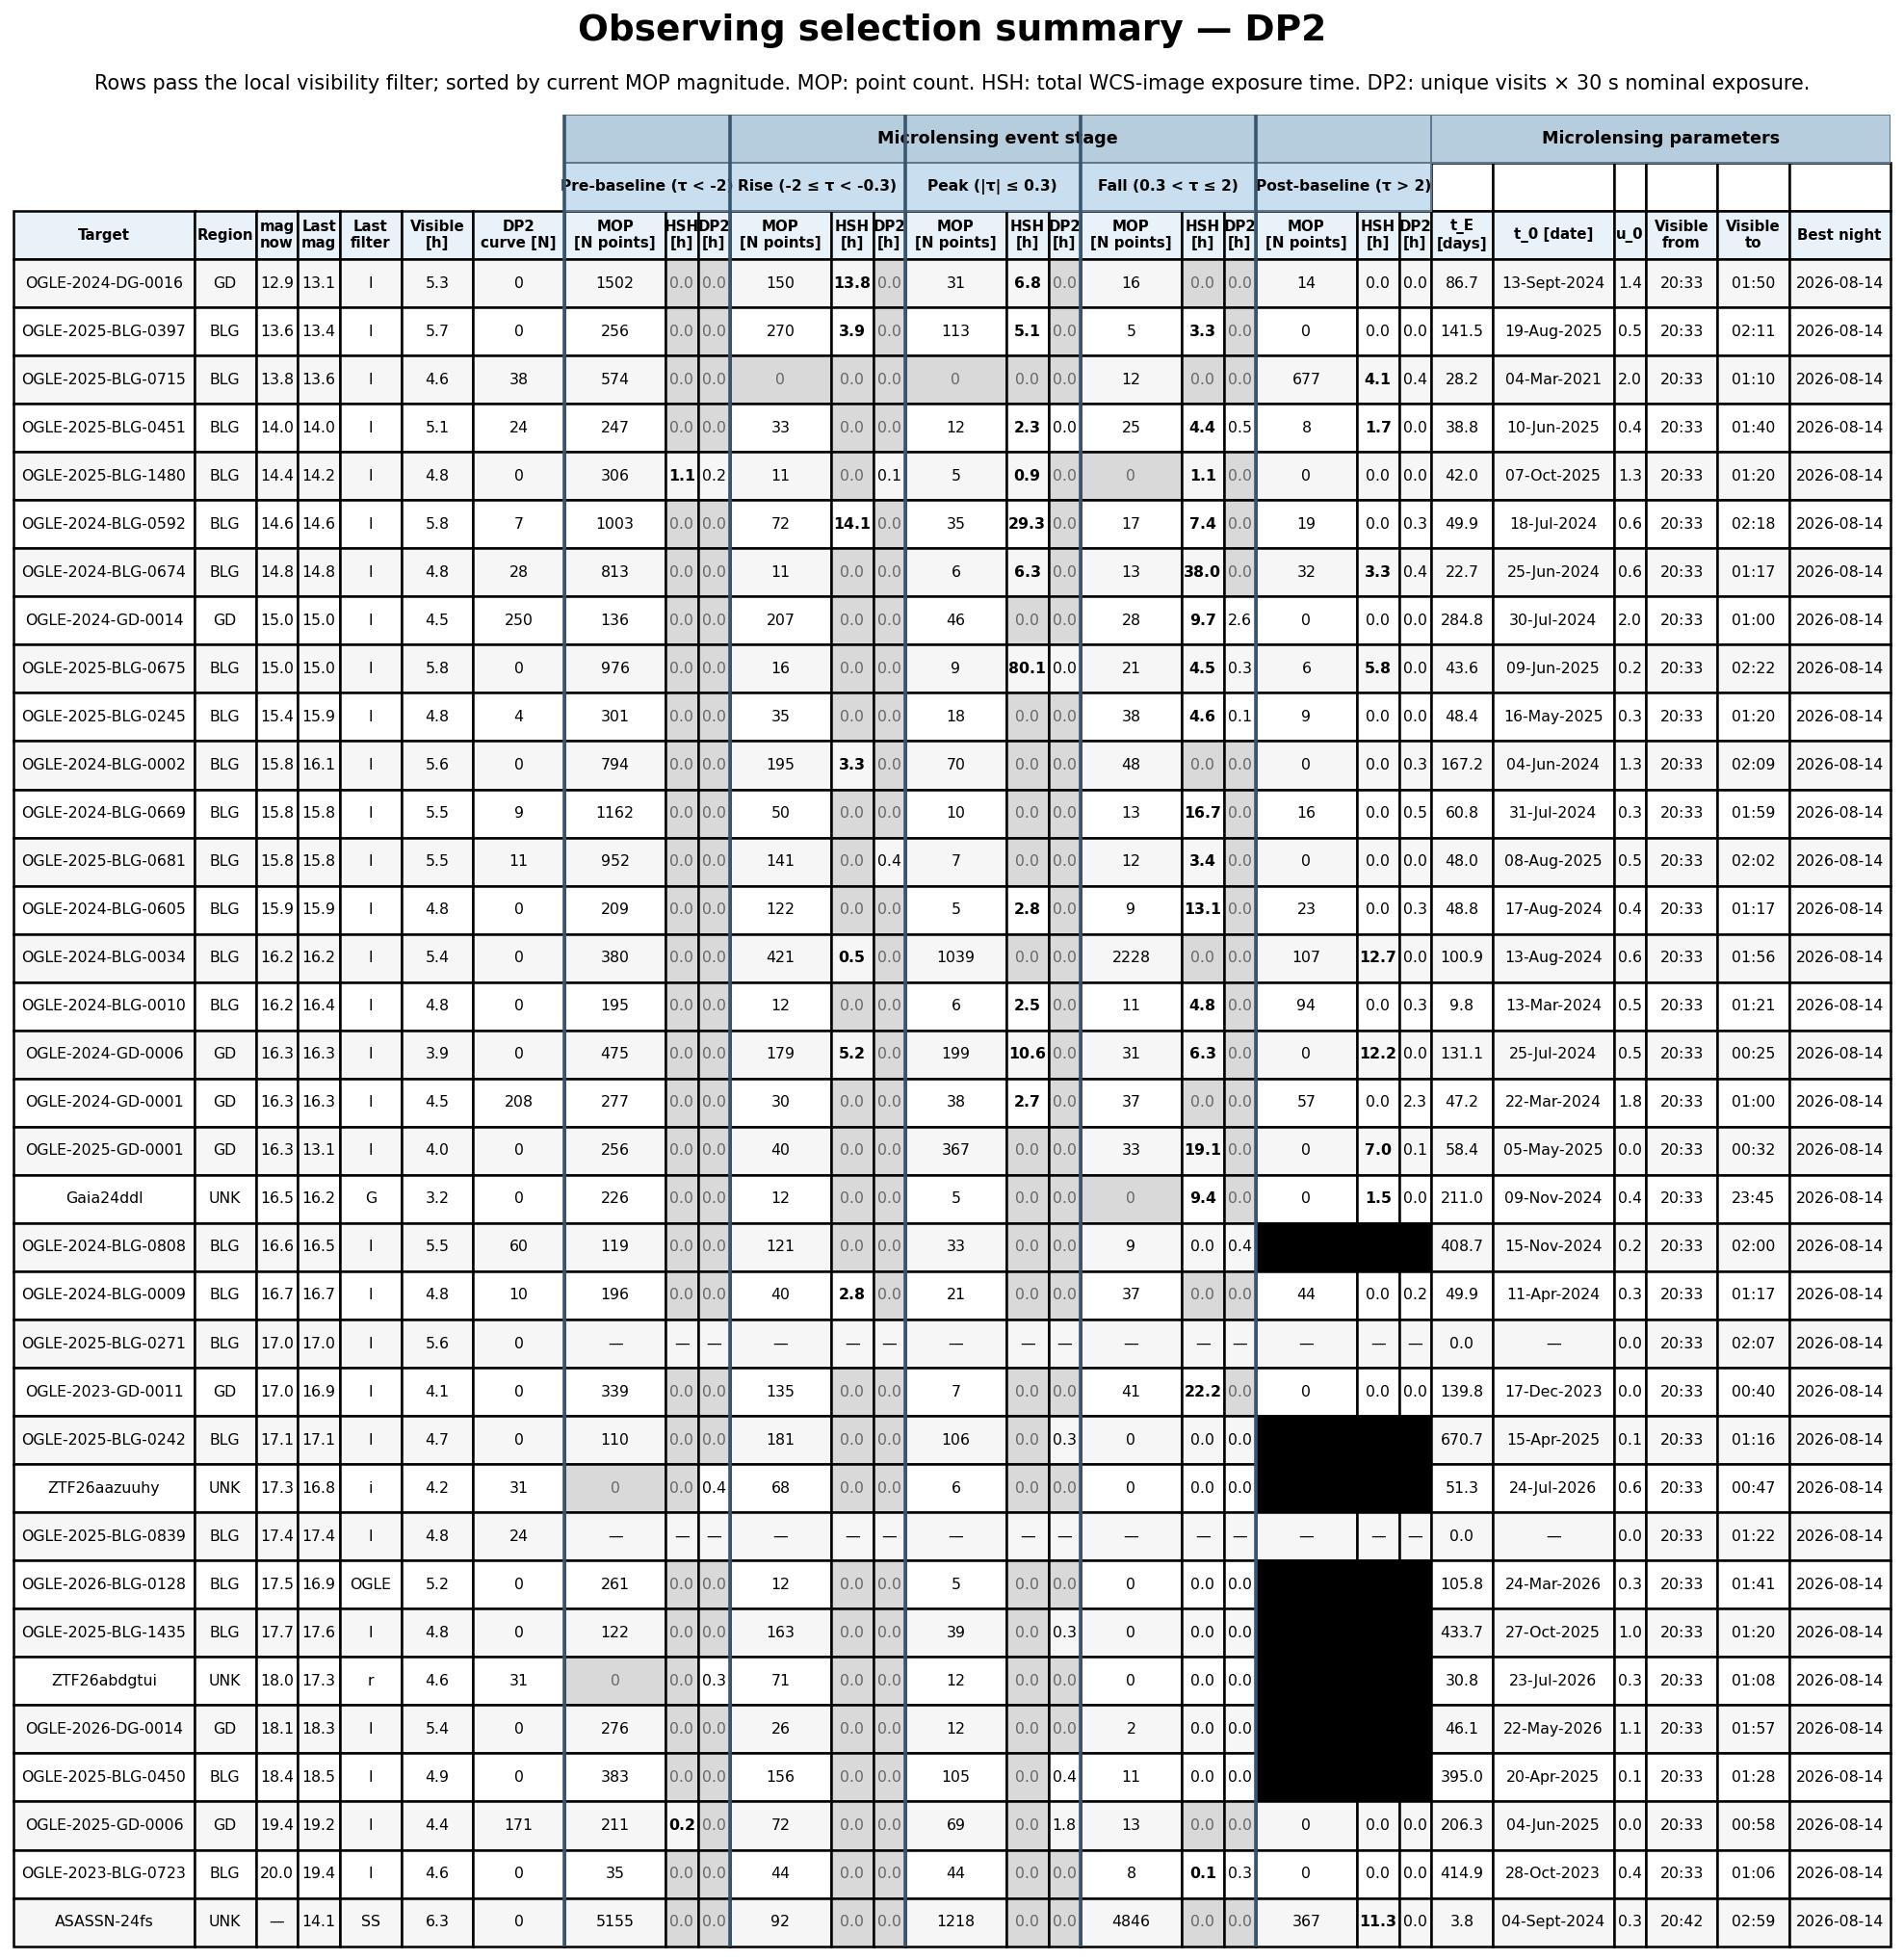

#### Complete target summary

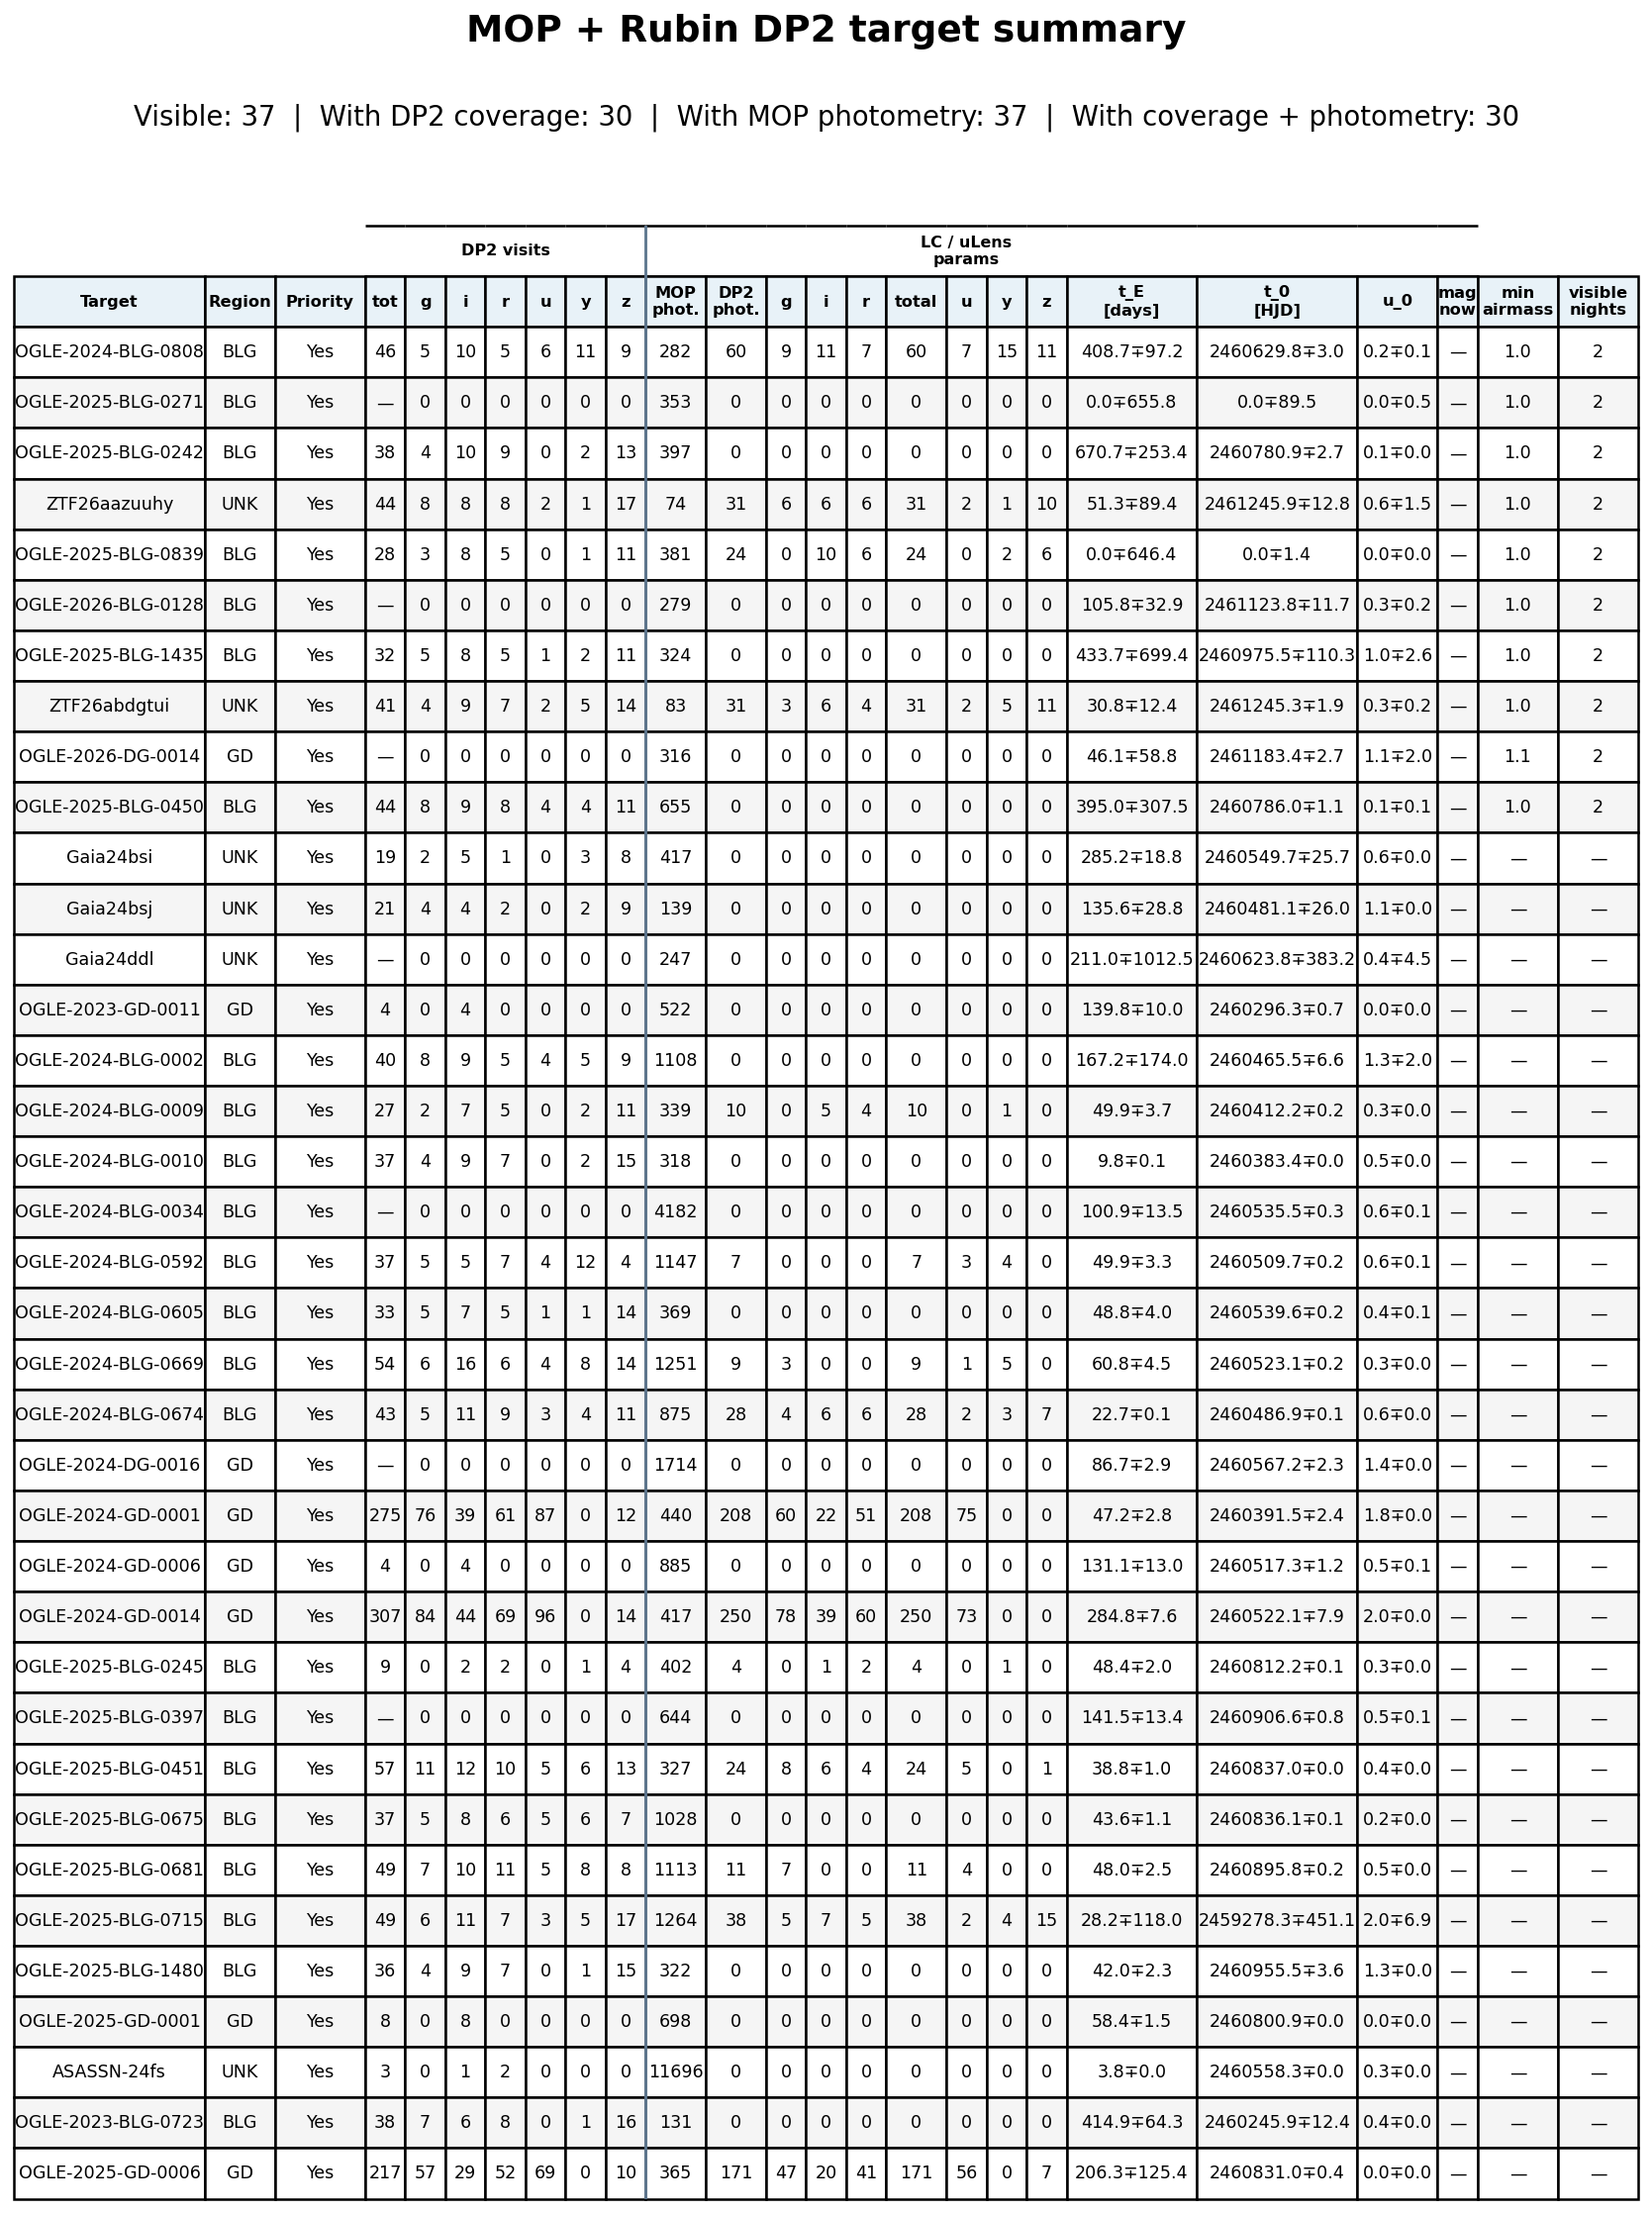

True

In [8]:
display_image_if_present(
    tables_dir / "observing_selection_summary.png",
    heading="Observing selection summary",
)
display_image_if_present(
    tables_dir / "target_summary.png",
    heading="Complete target summary",
)


### Nightly visibility gallery


Nightly visibility plots: 6


#### 2026-08-14 part 01 mop only visibility

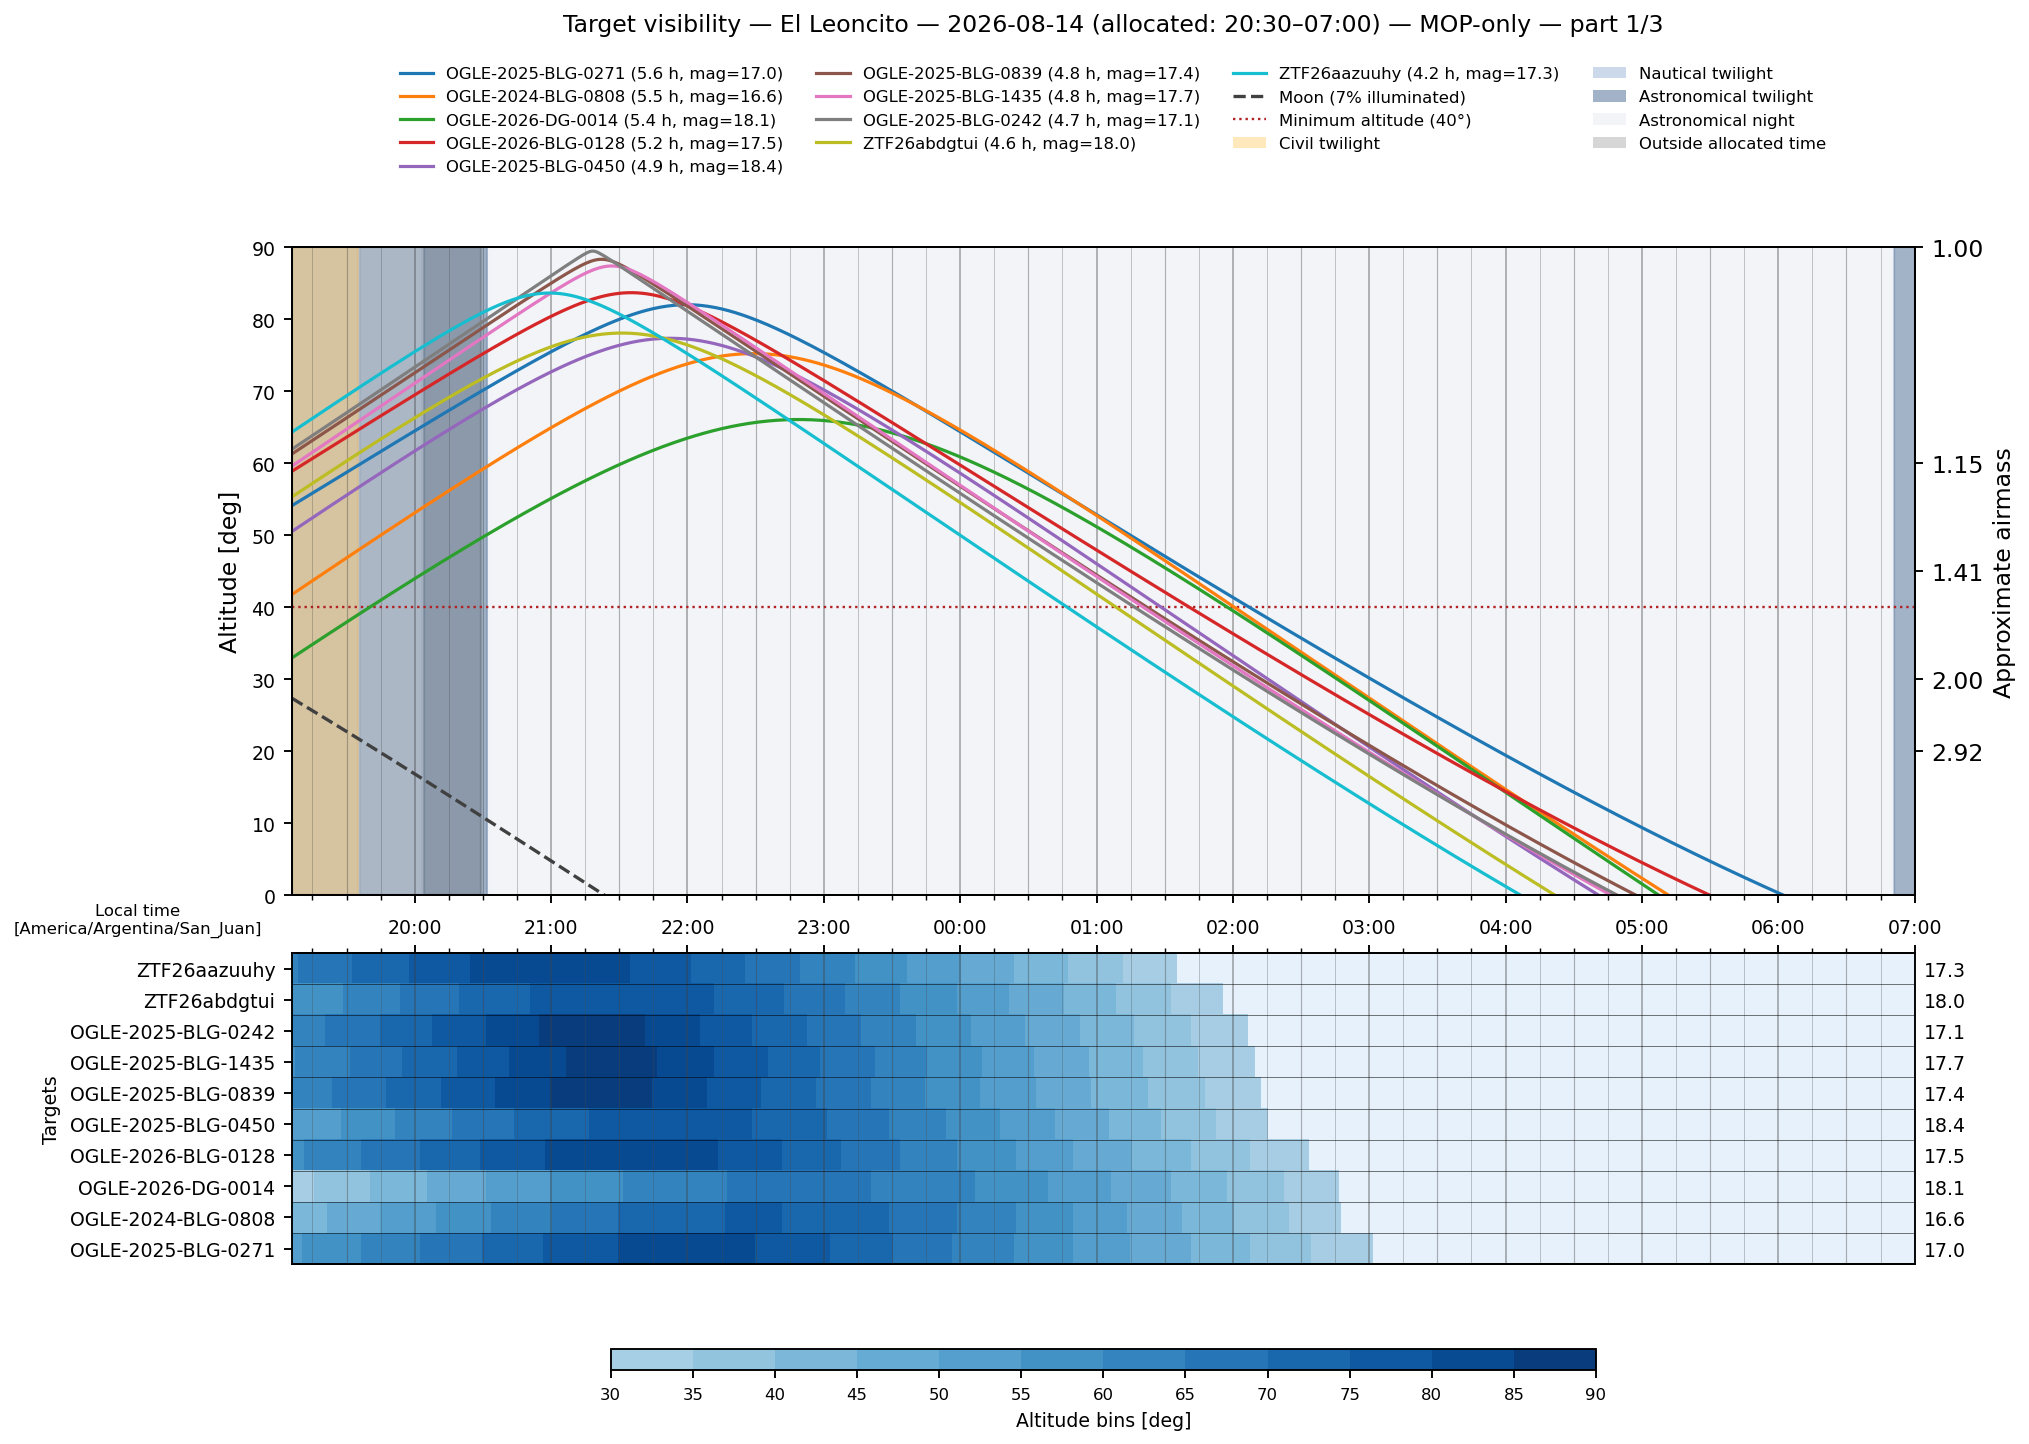

#### 2026-08-14 part 02 hsh js observed visibility

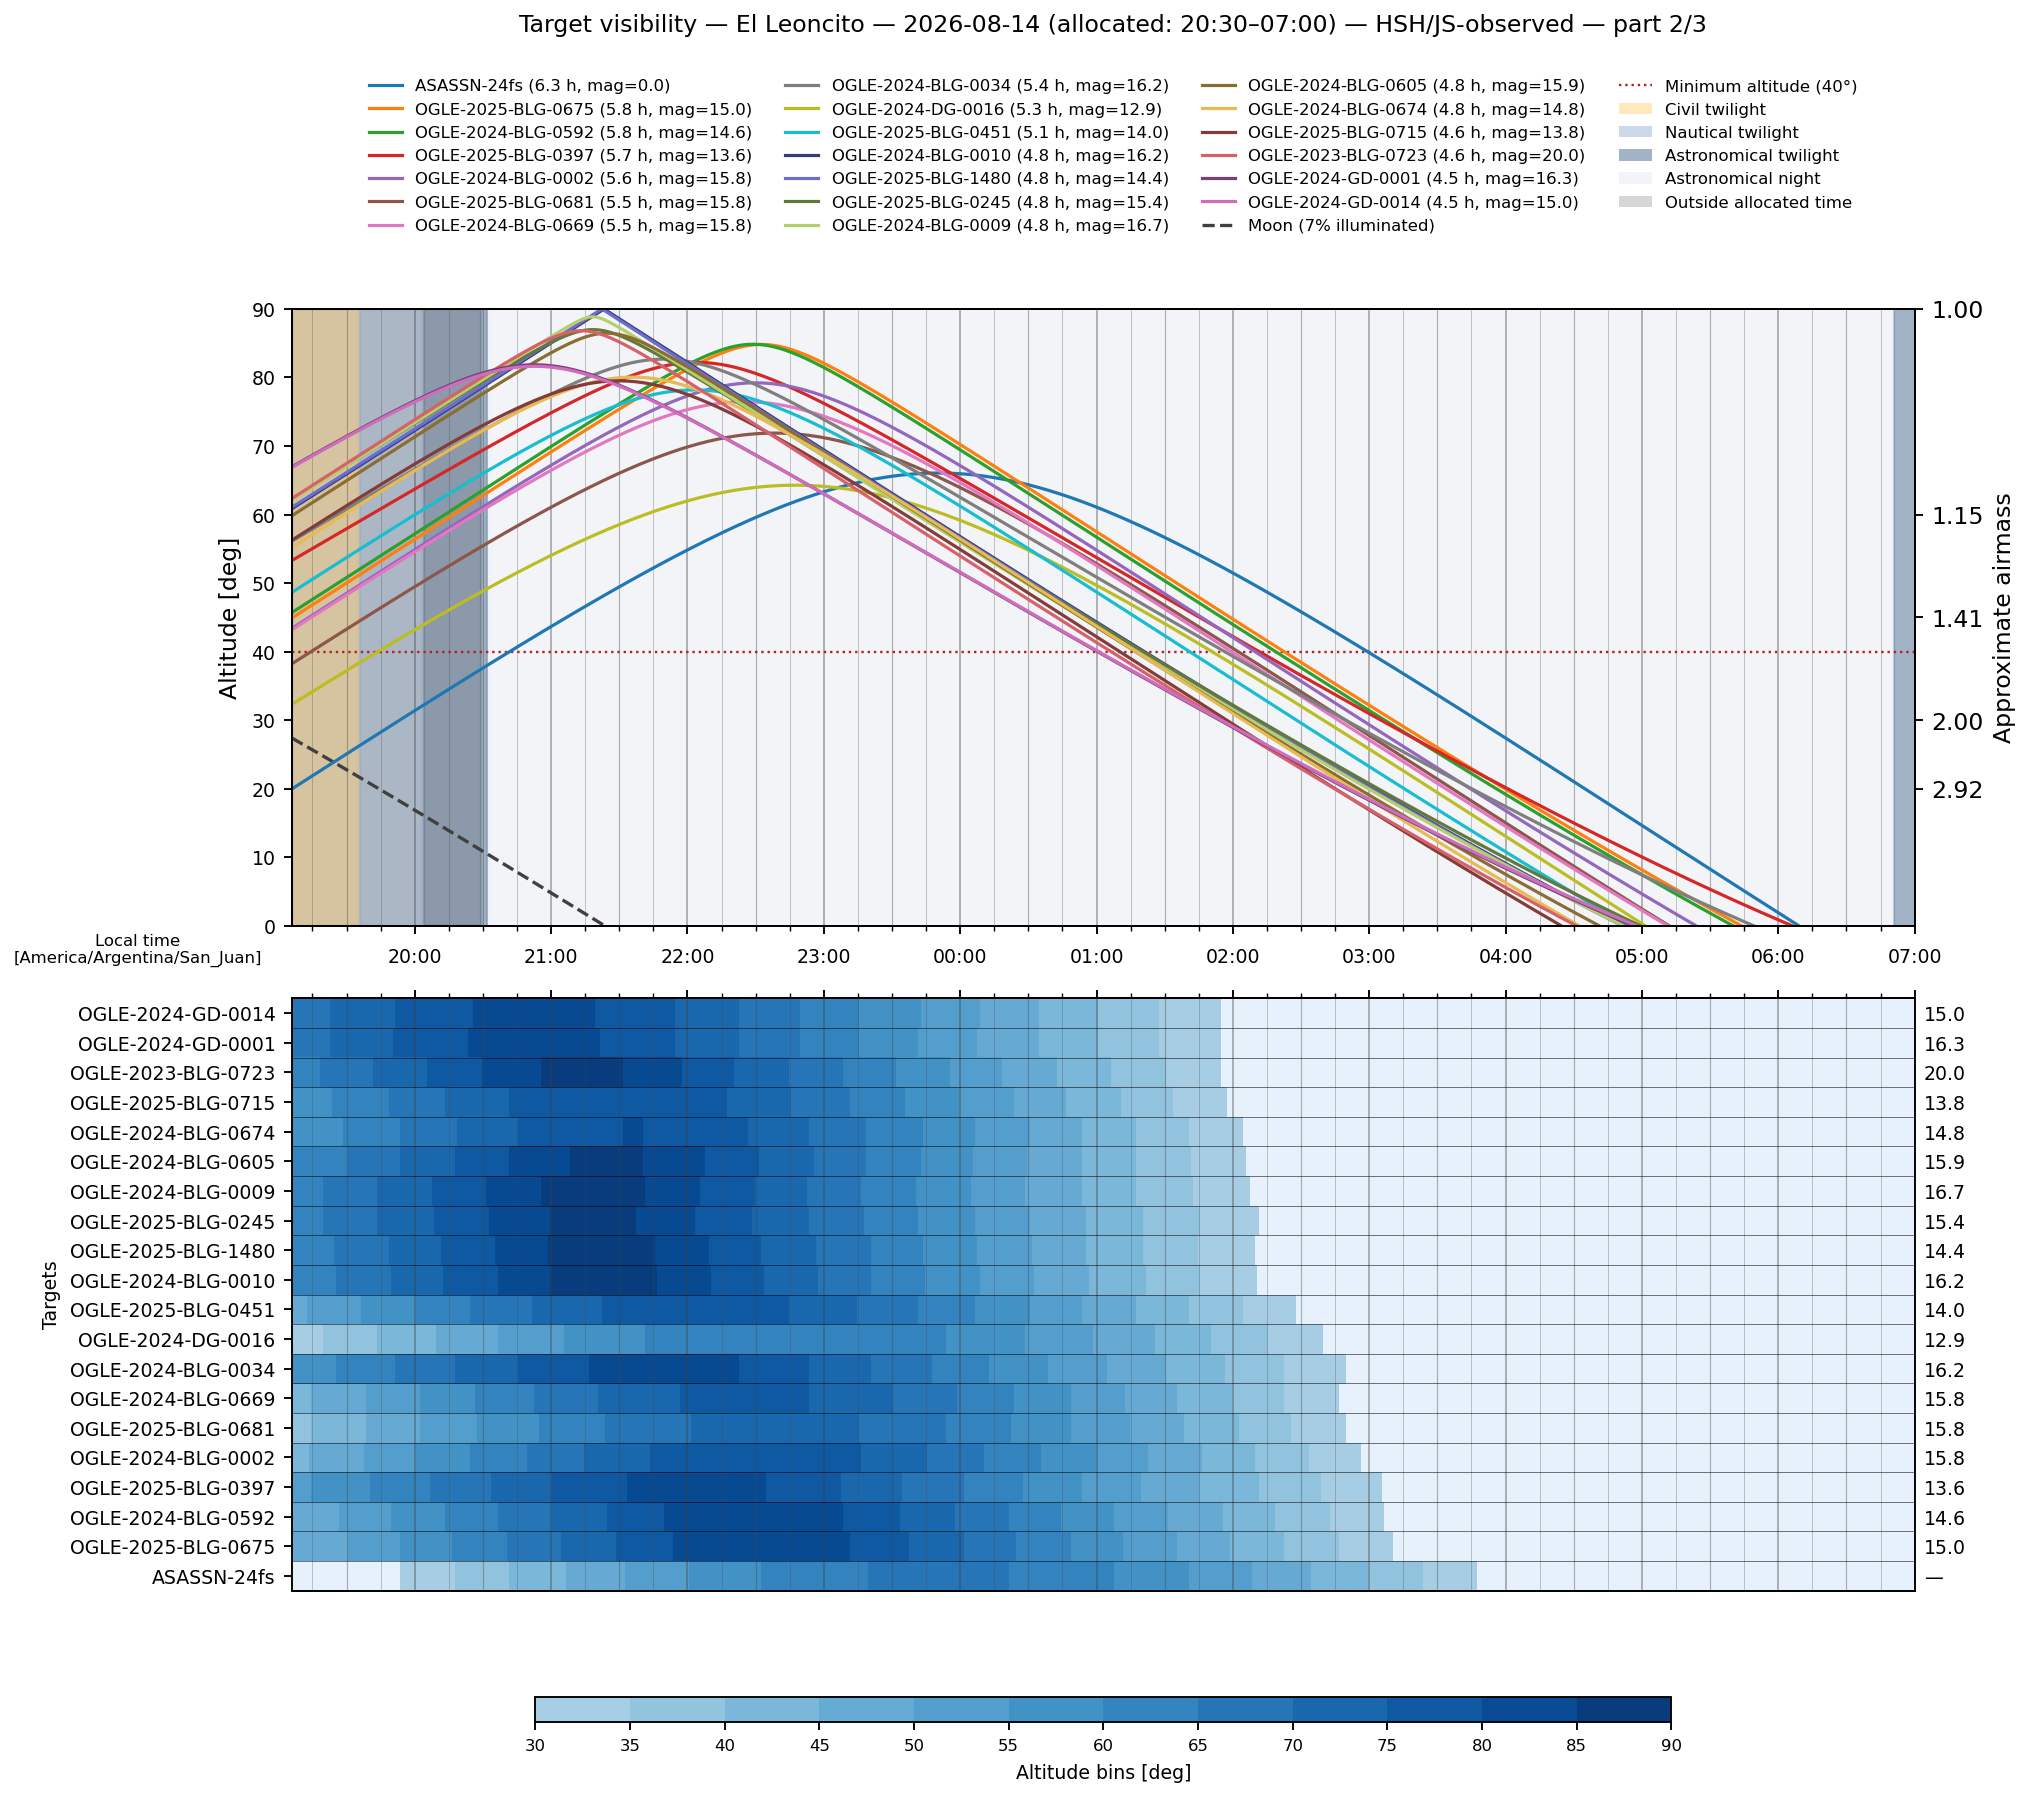

#### 2026-08-14 part 03 hsh js observed visibility

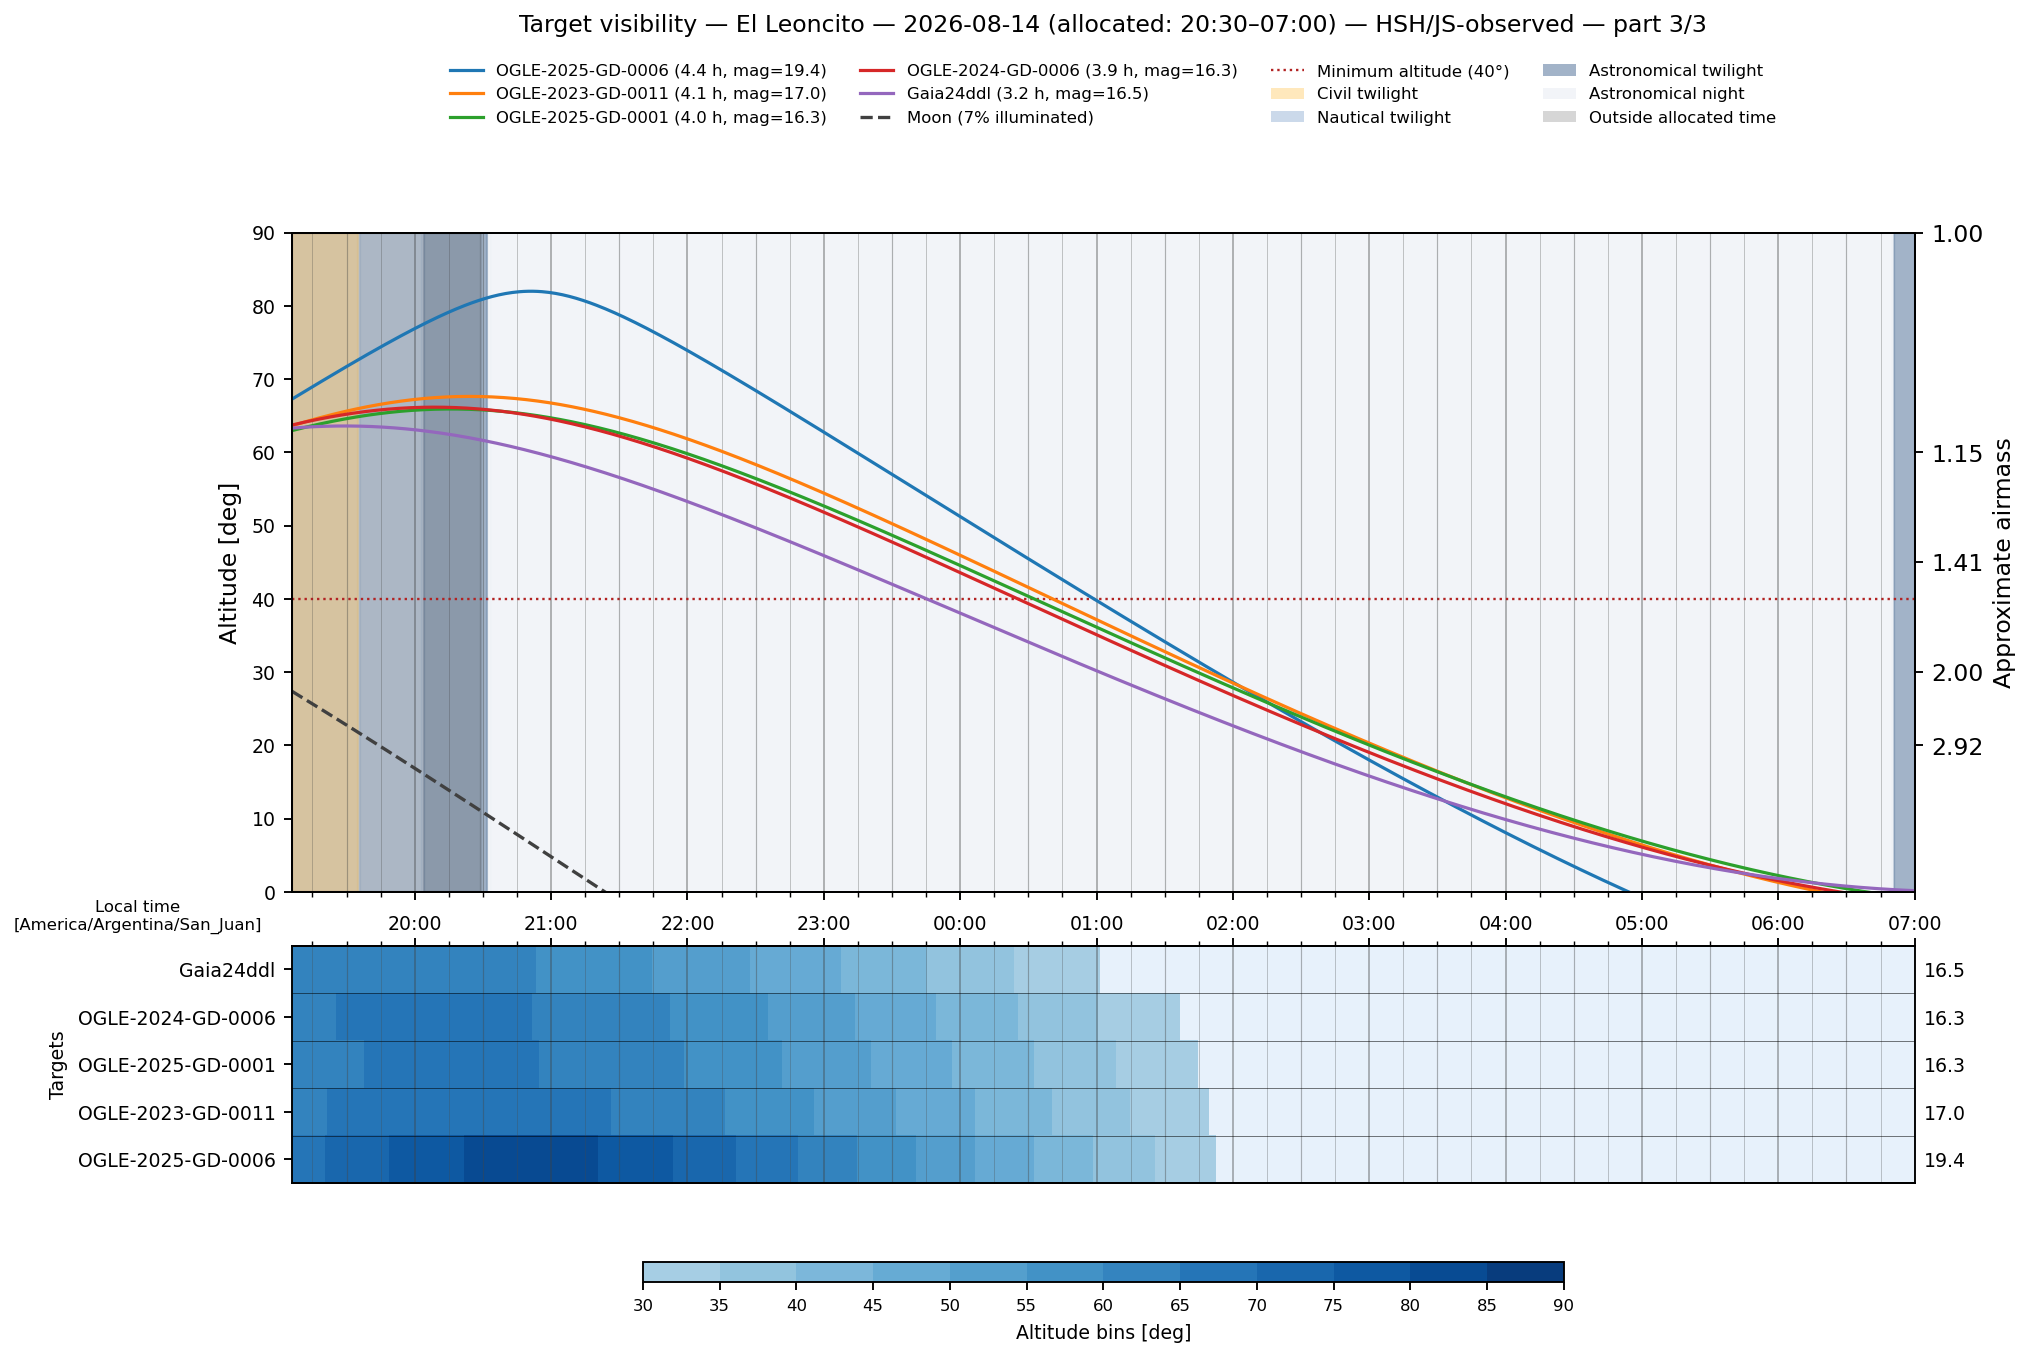

In [9]:
MAX_VISIBILITY_PLOTS = 3
visibility_dir = paths.get("visibility_plots", run_dir / "visibility_plots")
visibility_paths = sorted(visibility_dir.glob("*_visibility.png"))
print(f"Nightly visibility plots: {len(visibility_paths)}")
for visibility_path in visibility_paths[:MAX_VISIBILITY_PLOTS]:
    display_image_if_present(
        visibility_path,
        width=1050,
        heading=visibility_path.stem.replace("_", " "),
    )


### Chronological visibility PDF

Create one PDF with the locally selected targets for every requested night, stacked in chronological order.

In [10]:
from visibility_plotter import compile_visibility_plot_pages

# This PDF embeds the already-generated nightly PNGs. Each page is one date
# and preserves every source-aware part exactly as plotted.
sequence_path = compile_visibility_plot_pages(
    visibility_dir,
    visibility_dir / "visibility_sequence.pdf",
)
print(f"Chronological visibility PDF: {sequence_path.resolve()}")


Chronological visibility PDF: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/visibility_plots/visibility_sequence.pdf


### Monitoring PDF and sky maps


In [11]:
monitoring_dir = paths.get("monitoring_reports", run_dir / "monitoring_reports")
display_file_link_if_present(
    monitoring_dir / "lightcurves.pdf",
    "Open monitoring light curves",
)

sky_dir = paths.get("sky_plots", run_dir / "sky_plots")
sky_paths = sorted(sky_dir.glob("*.png"))
print(f"Sky maps: {len(sky_paths)}")
for sky_path in sky_paths:
    display_image_if_present(
        sky_path,
        width=1050,
        heading=sky_path.stem.replace("_", " "),
    )


[Open monitoring light curves](/home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/monitoring_reports/lightcurves.pdf)

Sky maps: 0


### Individual target reports

These are optional and are normally enabled only for detailed Rubin coadd inspection.


In [12]:
MAX_TARGET_REPORTS = 3
reports_dir = paths.get("targets", run_dir / "targets")
report_paths = sorted(reports_dir.glob("*_target_report.png"))
print(f"Individual target reports: {len(report_paths)}")
for report_path in report_paths[:MAX_TARGET_REPORTS]:
    display_image_if_present(
        report_path,
        width=1300,
        heading=report_path.name.removesuffix("_target_report.png"),
    )


Individual target reports: 0


### Optional reference forced photometry

For Early DP2, this is PSF photometry measured at the exact target coordinate on available deep coadds. Individual calibrated visit images are not used by this workflow.


In [13]:
reference_photometry_path = tables_dir / "release_forced_photometry.csv"
if reference_photometry_path.exists():
    reference_photometry = pd.read_csv(reference_photometry_path)
    display(reference_photometry.head(50))
    print(f"Rows: {len(reference_photometry)}")
    print(f"File: {reference_photometry_path.resolve()}")
else:
    print("Reference photometry was not requested or is unavailable in this mode.")


,Target,RA_deg,Dec_deg,visitId,detector,expMidptMJD,band,dataset_type,inst_flux,inst_flux_err,...,direct_flux_njy,direct_flux_err_njy,direct_flux_flag,difference_flux_njy,difference_flux_err_njy,difference_flux_flag,tract,patch,coadd_epoch_mjd,epoch_definition
0,OGLE-2024-BLG-0808,276.08,-17.074306,2.025062e+12,128.0,60848.107026,g,ForcedSourceOnDiaObject,1.173870e+04,168.039001,...,1.173870e+04,168.039001,0.0,319.317993,194.041000,0.0,NaN,NaN,NaN,NaN
1,OGLE-2024-BLG-0808,276.08,-17.074306,2.025062e+12,135.0,60848.107026,g,ForcedSourceOnDiaObject,6.955630e+02,128.320000,...,6.955630e+02,128.320000,0.0,10.945600,146.933000,0.0,NaN,NaN,NaN,NaN
2,OGLE-2024-BLG-0808,276.08,-17.074306,2.025062e+12,128.0,60848.131377,r,ForcedSourceOnDiaObject,1.062790e+05,338.350006,...,1.062790e+05,338.350006,0.0,10321.700195,451.199005,0.0,NaN,NaN,NaN,NaN
3,OGLE-2024-BLG-0808,276.08,-17.074306,2.025062e+12,135.0,60848.131377,r,ForcedSourceOnDiaObject,7.854970e+03,209.951000,...,7.854970e+03,209.951000,0.0,625.850000,275.916000,0.0,NaN,NaN,NaN,NaN
4,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,56.0,60858.028620,i,ForcedSourceOnDiaObject,4.595610e+05,1436.219971,...,4.595610e+05,1436.219971,0.0,35124.199219,1766.829956,0.0,NaN,NaN,NaN,NaN
5,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,56.0,60858.053680,z,ForcedSourceOnDiaObject,1.063970e+06,2466.969971,...,1.063970e+06,2466.969971,0.0,0.000000,3128.500000,0.0,NaN,NaN,NaN,NaN
6,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,56.0,60858.104121,z,ForcedSourceOnDiaObject,1.078390e+06,5094.339844,...,1.078390e+06,5094.339844,0.0,0.000000,5465.490234,0.0,NaN,NaN,NaN,NaN
7,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,56.0,60858.146916,i,ForcedSourceOnDiaObject,4.558390e+05,1071.270020,...,4.558390e+05,1071.270020,0.0,56215.699219,1477.599976,0.0,NaN,NaN,NaN,NaN
8,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,63.0,60858.146916,i,ForcedSourceOnDiaObject,2.360720e+03,698.334000,...,2.360720e+03,698.334000,1.0,-53714.100000,857.138000,1.0,NaN,NaN,NaN,NaN
9,OGLE-2024-BLG-0808,276.08,-17.074306,2.025070e+12,82.0,60859.120925,i,ForcedSourceOnDiaObject,-1.305250e+03,359.989000,...,-1.305250e+03,359.989000,0.0,232.684000,603.162000,0.0,NaN,NaN,NaN,NaN


Rows: 941
File: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/tables/release_forced_photometry.csv


## 5. Export a copyable observer list

The export can include every analyzed target or only targets that pass the local visibility cut. It optionally applies a current-magnitude limit and labels events as previously observed by HSH or new to the MOP selection.


In [14]:
from astropy.coordinates import SkyCoord
import astropy.units as u

COORDINATE_SCOPE = "selected"  # "selected" or "all"
COORDINATE_MAX_MAGNITUDE = 16.1  # None keeps targets with any or missing magnitude
COORDINATE_DECIMALS = 3

coordinate_targets = targets.copy()
if COORDINATE_SCOPE == "selected":
    if "passes_visibility_filter" in coordinate_targets:
        selected_mask = coordinate_targets["passes_visibility_filter"].astype(str).str.lower().eq("true")
        coordinate_targets = coordinate_targets.loc[selected_mask].copy()
    elif not visibility_table.empty and "Target" in visibility_table and decision_column in visibility_table:
        selected_names = visibility_table.loc[
            visibility_table[decision_column].astype(str).str.lower().eq("true"), "Target"
        ].astype(str)
        coordinate_targets = coordinate_targets.loc[
            coordinate_targets["Target"].astype(str).isin(selected_names)
        ].copy()
elif COORDINATE_SCOPE != "all":
    raise ValueError("COORDINATE_SCOPE must be 'selected' or 'all'.")

magnitude_columns = [
    column for column in ("mag_now", "mop_mag_now", "mag_now_x", "mag_now_y")
    if column in coordinate_targets
]
coordinate_targets["export_mag_now"] = (
    coordinate_targets[magnitude_columns]
    .apply(pd.to_numeric, errors="coerce")
    .bfill(axis=1)
    .iloc[:, 0]
    if magnitude_columns else float("nan")
)
if COORDINATE_MAX_MAGNITUDE is not None:
    magnitude = coordinate_targets["export_mag_now"]
    coordinate_targets = coordinate_targets.loc[
        magnitude.isna() | magnitude.le(float(COORDINATE_MAX_MAGNITUDE))
    ].copy()

hsh_count_columns = [
    column for column in ("hsh_n_astrometric", "hsh_n_images", "HSH_n_images")
    if column in coordinate_targets
]
coordinate_targets["export_hsh_count"] = (
    coordinate_targets[hsh_count_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .max(axis=1)
    if hsh_count_columns else 0
)
post_baseline_columns = [
    column for column in ("hsh_post_baseline_n", "HSH_post_baseline_n")
    if column in coordinate_targets
]
coordinate_targets["export_post_baseline"] = (
    coordinate_targets[post_baseline_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .max(axis=1)
    if post_baseline_columns else 0
)

coordinate_targets = coordinate_targets.dropna(subset=["RA_deg", "Dec_deg"]).sort_values("RA_deg")
coordinates = SkyCoord(
    coordinate_targets["RA_deg"].to_numpy() * u.deg,
    coordinate_targets["Dec_deg"].to_numpy() * u.deg,
)

labels = []
for row in coordinate_targets.itertuples(index=False):
    magnitude = row.export_mag_now
    magnitude_label = f"{magnitude:.2f}" if pd.notna(magnitude) else "no_mag"
    observed_hsh = row.export_hsh_count > 0
    status_label = "obsHSH" if observed_hsh else "newMOP"
    baseline_label = "_needBaseline" if observed_hsh and row.export_post_baseline <= 0 else ""
    labels.append(f"{row.Target}_{magnitude_label}_{status_label}{baseline_label}")

coordinate_export_text = "\n".join(
    f"{coordinate.ra.to_string(unit=u.hourangle, sep=':', precision=COORDINATE_DECIMALS, pad=True)} "
    f"{coordinate.dec.to_string(unit=u.deg, sep=':', precision=COORDINATE_DECIMALS, pad=True, alwayssign=True)} "
    f"{label}"
    for coordinate, label in zip(coordinates, labels, strict=True)
)
print(coordinate_export_text)


16:47:23.830 -40:07:06.600 OGLE-2024-GD-0014_14.99_obsHSH_needBaseline
17:13:11.480 -34:47:07.400 OGLE-2025-BLG-0245_15.38_obsHSH_needBaseline
17:17:08.580 -31:44:58.600 OGLE-2025-BLG-1480_14.38_obsHSH_needBaseline
17:19:27.760 -28:13:39.900 OGLE-2024-BLG-0605_15.89_obsHSH_needBaseline
17:24:42.610 -21:16:46.400 OGLE-2025-BLG-0715_13.75_obsHSH
17:30:56.620 -21:49:42.400 OGLE-2024-BLG-0674_14.80_obsHSH
17:58:09.830 -19:58:40.800 OGLE-2025-BLG-0451_13.99_obsHSH
17:58:51.170 -39:35:50.400 OGLE-2025-BLG-0397_13.56_obsHSH_needBaseline
18:20:21.390 -18:16:09.800 OGLE-2024-BLG-0669_15.79_obsHSH_needBaseline
18:23:54.340 -26:39:09.800 OGLE-2024-BLG-0592_14.59_obsHSH_needBaseline
18:25:00.190 -21:01:43.400 OGLE-2024-BLG-0002_15.76_obsHSH_needBaseline
18:27:39.680 -26:37:43.700 OGLE-2025-BLG-0675_15.00_obsHSH
18:33:34.010 -13:42:11.200 OGLE-2025-BLG-0681_15.81_obsHSH_needBaseline
18:42:39.870 -06:06:25.400 OGLE-2024-DG-0016_12.89_obsHSH_needBaseline
19:45:58.937 -07:55:29.130 ASASSN-24fs_0.00_ob

## 6. Audit data reuse and provenance

These tables explain which source data were imported or refreshed and which providers or surveys contributed each persistent target.


In [15]:
display(Markdown("### Source updates in this run"))
display(analysis_result.source_updates)

source_catalog_path = tables_dir / "source_catalog.csv"
if source_catalog_path.exists():
    source_catalog = pd.read_csv(source_catalog_path)
    display(Markdown("### Persistent source catalog"))
    display(source_catalog.head(100))

configuration_snapshot = run_dir / "analysis_config.json"
database_path = Path(config.cache.database_path)
if not database_path.is_absolute():
    database_path = Path(config.output_dir) / database_path

print(f"Configuration snapshot: {configuration_snapshot.resolve()}")
print(f"Persistent registry: {database_path.resolve()}")
print(f"Product index: {product_index_path.resolve()}")


### Source updates in this run

,source,role,records_updated,photometry_updated
0,casleo_hsh,followup_survey,0,NaN
1,rubin_dp2,reference_survey,37,919.0


### Persistent source catalog

,Target,RA_deg,Dec_deg,coordinate_source,coordinate_priority,source_name,source_role,source_observed_at,record_json,updated_utc
0,ASASSN-24fs,296.495571,-7.924758,MOP target page,100,casleo_hsh,followup_survey,NaN,"{""Dec_deg"": -7.924758333333334, ""RA_deg"": 296....",2026-08-16T04:08:25+00:00
1,ASASSN-24fs,296.495571,-7.924758,MOP target page,100,rubin_dp2,reference_survey,NaN,"{""Dec_deg"": -7.924758333333334, ""RA_deg"": 296....",2026-08-16T04:24:14+00:00
2,ASASSN-24fs,296.495571,-7.924758,MOP target page,100,mop,target_provider,NaN,"{""Dec"": null, ""Dec_deg"": -7.924758333333334, ""...",2026-08-16T04:24:14+00:00
3,Gaia24bsi,82.597058,-70.039561,MOP target page,100,casleo_hsh,followup_survey,NaN,"{""Dec_deg"": -70.03956111111111, ""RA_deg"": 82.5...",2026-08-16T04:08:25+00:00
4,Gaia24bsi,82.597058,-70.039561,MOP target page,100,rubin_dp2,reference_survey,NaN,"{""Dec_deg"": -70.03956111111111, ""RA_deg"": 82.5...",2026-08-16T04:24:14+00:00
...,...,...,...,...,...,...,...,...,...,...
95,OGLE-2026-DG-0014,281.054750,-7.931889,MOP target page,100,rubin_dp2,reference_survey,NaN,"{""Dec_deg"": -7.931888888888889, ""RA_deg"": 281....",2026-08-16T04:24:14+00:00
96,OGLE-2026-DG-0014,281.054750,-7.931889,MOP target page,100,mop,target_provider,NaN,"{""Dec"": ""-7d55m54.8s"", ""Dec_deg"": -7.931888888...",2026-08-16T04:24:14+00:00
97,ZTF26aazuuhy,253.529758,-25.428064,MOP target page,100,rubin_dp2,reference_survey,NaN,"{""Dec_deg"": -25.42806388888889, ""RA_deg"": 253....",2026-08-16T04:24:14+00:00
98,ZTF26aazuuhy,253.529758,-25.428064,MOP target page,100,mop,target_provider,NaN,"{""Dec"": ""-25d25m41.02903545s"", ""Dec_deg"": -25....",2026-08-16T04:24:14+00:00


Configuration snapshot: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/analysis_config.json
Persistent registry: /home/karennowo/target_selection/outputs/target_database/target_selection.sqlite
Product index: /home/karennowo/target_selection/outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00/product_index.json


## What to change and rerun

1. **New dates, telescope allocation, source combination, or magnitude cut:** edit the top sections of your TOML file and rerun from section 1.
2. **Only a different plot/report choice:** change `[products]`; compatible source and query caches are reused.
3. **A changed HSH/JS CSV:** rerun normally; file fingerprints trigger reimport. Use the role-specific refresh switch only when a forced refresh is required.
4. **An interrupted run:** keep cache reuse enabled and overwrite switches disabled, then rerun the analysis cell.
5. **Batch/reproducible execution:** use `target-selection run --config configs/my_run.toml` instead of the notebook.

The full conceptual explanation and extension guide remain in `docs/`; this notebook demonstrates the public interface and the actual generated products.


# One target run

In [2]:
from target_selection import load_config, run_analysis

config = load_config("configs/one_target.toml")
analysis_result = run_analysis(config)

[1/5] Visible MOP targets (disabled)
[2/5] MOP parameters + photometry
      Local visibility selection skipped
      Rubin query targets: 1 (0 MOP-visible, 0 previously observed only, 1 user supplied)
        OGLE-2025-BLG-1121
[3/5] DP2 coverage (4 workers)


/home/karennowo/target_selection/target_selection_pipeline.py:1436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([visible_summary, observed_only, user_targets], ignore_index=True, sort=False)


[4/6] DP2 DIA forced photometry (1 targets)


DIA forced photometry:   0%|          | 0/1 [00:00<?, ?target/s]

[5/6] Tables and sky maps
[6/6] Per-target reports (all_queried: 1 targets)
Legend — reused: current PNG; migrated: matching previous PNG; generated: new PNG; no coadd: newly confirmed missing coadd; cached no coadd: previously confirmed; errors: isolated failures.


Reports: 100%|██████████| 1/1 [00:33<00:00, 33.82s/target, cached_no_coadd=0, errors=0, generated=1, migrated=0, no_coadd=0, reused=0]

Reports complete: generated=1, reused=0, no coadd=0, errors=0
Pipeline completed in 0.9 min
